In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow.keras as k

In [3]:
data = pd.read_csv("Churn_Modelling.csv")

In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
def checkOutlier(data, col):
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col,kde=True)
    plt.axvline(data[col].mean()+(3*data[col].std()),color='red')
    plt.axvline(data[col].mean()-(3*data[col].std()),color='red')

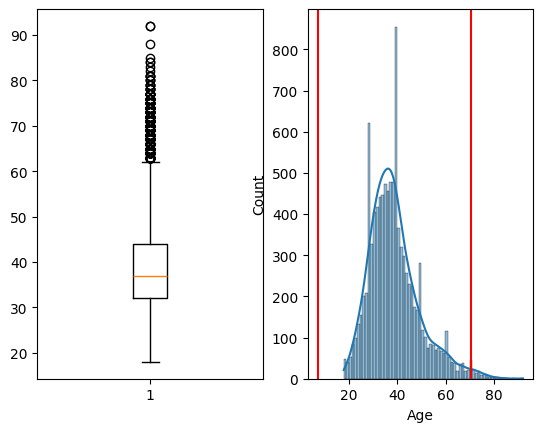

In [7]:
checkOutlier(data,"Age")


In [8]:
def checkOutlier(data, col):
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col,kde=True)
    plt.axvline(data[col].mean()+(3*data[col].std()),color='red')
    plt.axvline(data[col].mean()-(3*data[col].std()),color='red')

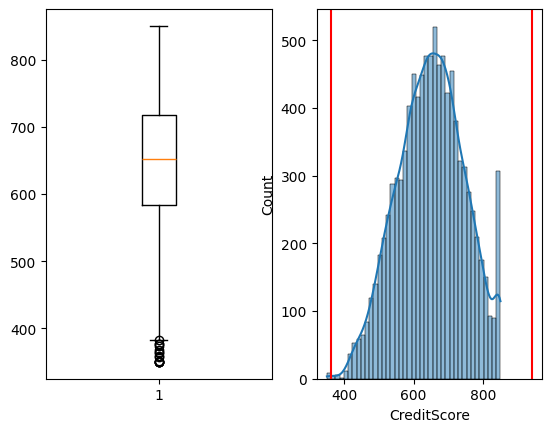

In [9]:
checkOutlier(data,"CreditScore")

In [10]:
def handleOutliers(data, col):
    q3 = data[col].quantile(0.75)
    q1 = data[col].quantile(0.25)
    iqr = q3-q1
    upper = q3 + (1.5*iqr)
    lower =q1 - (1.5*iqr)
    data.loc[data[col]>upper,col ] = upper 
    data.loc[data[col]<lower,col ] = lower 

In [11]:
handleOutliers(data,"CreditScore")

In [12]:
handleOutliers(data,"Age")

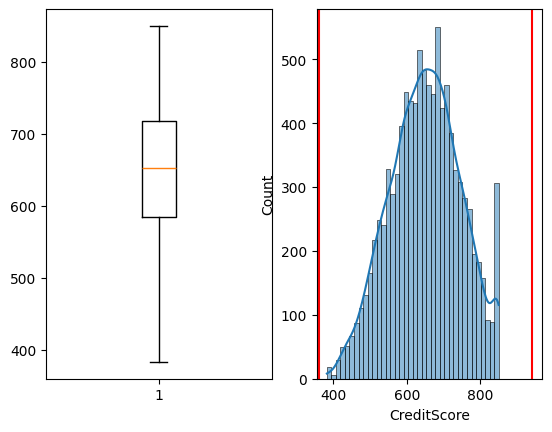

In [13]:
checkOutlier(data,"CreditScore")

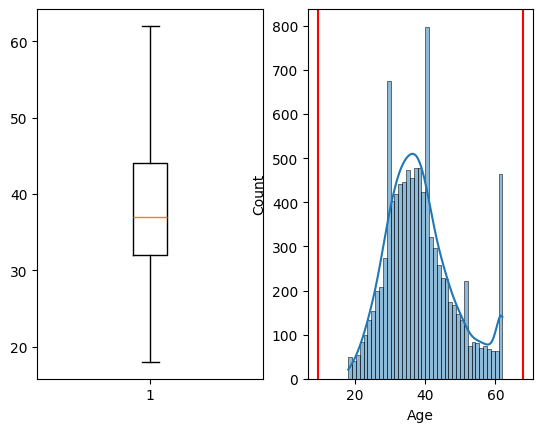

In [14]:
checkOutlier(data,"Age")


In [15]:
data.drop(["RowNumber","CustomerId","Surname"],inplace=True,axis = 1)

In [16]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
data["Exited"].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

In [18]:
data["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [19]:
data["Geography"] = data["Geography"].replace({'France':0, 'Spain':1, 'Germany':2})
data["Gender"] = data["Gender"].replace({"Female":0,"Male":1})

C:\Users\Dipak\AppData\Local\Temp\ipykernel_11120\3596649616.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Geography"] = data["Geography"].replace({'France':0, 'Spain':1, 'Germany':2})
C:\Users\Dipak\AppData\Local\Temp\ipykernel_11120\3596649616.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Gender"] = data["Gender"].replace({"Female":0,"Male":1})


In [20]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0


In [21]:
X = data.drop("Exited",axis = 1)
y = data["Exited"]

In [22]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X,y = sm.fit_resample(X,y)

In [23]:
X.shape

(15926, 10)

In [24]:
y.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 0)

In [28]:
model = k.models.Sequential()
model.add(k.layers.Dense(units=10,activation="relu"))
model.add(k.layers.Dense(units=32,activation="relu"))
model.add(k.layers.Dense(units=1,activation="sigmoid"))

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # ✅ Correct spelling
    metrics=['accuracy']
)

In [35]:
# model.fit(X_train,y_train,epochs= 15,batch_size=50)
model.fit(X_train, y_train, epochs=15, batch_size=50)

Epoch 1/15


InvalidArgumentError: Graph execution error:

Detected at node StatefulPartitionedCall/sequential_1/dense_1/Relu defined at (most recent call last):
<stack traces unavailable>
In[1] is not a matrix
	 [[{{node StatefulPartitionedCall/sequential_1/dense_1/Relu}}]] [Op:__inference_multi_step_on_iterator_2889]

In [36]:
model.evaluate(X_test,y_test)

ValueError: Could not interpret loss identifier: binary_crossentrapy